In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("PJME_hourly.csv")

In [5]:
print(df.head(10))                                                                

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0
5  2002-12-31 06:00:00  26222.0
6  2002-12-31 07:00:00  28702.0
7  2002-12-31 08:00:00  30698.0
8  2002-12-31 09:00:00  31800.0
9  2002-12-31 10:00:00  32359.0


In [6]:
print(df.shape)

(145366, 2)


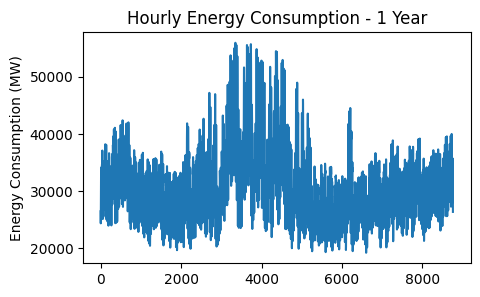

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(df['PJME_MW'][:8760])
plt.title('Hourly Energy Consumption - 1 Year')
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [8]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [9]:
df['hour']=df['Datetime'].dt.hour
df['dayofweek']=df['Datetime'].dt.dayofweek
df['month']=df['Datetime'].dt.month
df['year']=df['Datetime'].dt.year
print(df.head(5))

             Datetime  PJME_MW  hour  dayofweek  month  year
0 2002-12-31 01:00:00  26498.0     1          1     12  2002
1 2002-12-31 02:00:00  25147.0     2          1     12  2002
2 2002-12-31 03:00:00  24574.0     3          1     12  2002
3 2002-12-31 04:00:00  24393.0     4          1     12  2002
4 2002-12-31 05:00:00  24860.0     5          1     12  2002


In [10]:
X = df[['hour', 'dayofweek', 'month', 'year']]
y = df['PJME_MW']
print(X.head(5))
print(y.head(5))

   hour  dayofweek  month  year
0     1          1     12  2002
1     2          1     12  2002
2     3          1     12  2002
3     4          1     12  2002
4     5          1     12  2002
0    26498.0
1    25147.0
2    24574.0
3    24393.0
4    24860.0
Name: PJME_MW, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.head(5))
print(X_test.head(5))
print(y_train.head(5))
print(y_test.head(5))

        hour  dayofweek  month  year
14267     15          4      5  2003
83283      0          5      7  2011
80408      5          4     10  2011
128770    11          4      4  2016
7726       1          1      2  2002
        hour  dayofweek  month  year
139734     8          5      1  2017
57990     20          1      5  2008
79090      6          3     12  2011
16986     23          3      1  2003
26227      2          5      1  2004
14267     31136.0
83283     31689.0
80408     23950.0
128770    29428.0
7726      28681.0
Name: PJME_MW, dtype: float64
139734    27569.0
57990     31919.0
79090     25888.0
16986     40771.0
26227     24128.0
Name: PJME_MW, dtype: float64


In [13]:
from xgboost import XGBRegressor

In [14]:
model = XGBRegressor()
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [15]:
predictions = model.predict(X_test)
print(predictions[:5])
print(y_test[:5].values)

[30802.68  33413.074 28962.602 35240.332 32024.785]
[27569. 31919. 25888. 40771. 24128.]


In [16]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, predictions)
print(f'Root Mean Squared Error: {mse**0.5}')

Root Mean Squared Error: 2958.3094054057024


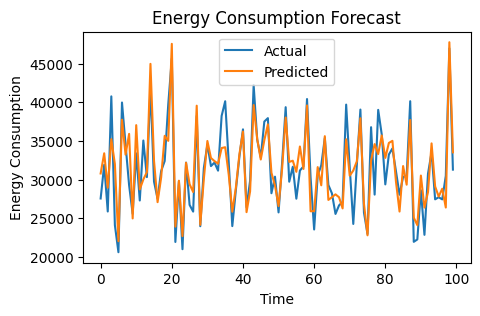

In [19]:
plt.figure(figsize=(5, 3))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')  
plt.xlabel('Time')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption Forecast')
plt.legend()
plt.show()